# TSTR Validation of the Physics-Informed Synthetic Data Generator
## Train-on-Synthetic, Test-on-Real Protocol for HVAC Predictive Maintenance

This notebook implements a Train-on-Synthetic, Test-on-Real (TSTR) validation of the PM v4.0 physics-informed synthetic data generator against three anonymised real-world maintenance event datasets (buildings A-79, B-2, B-5).

### Objective
Quantify the generalisation of predictive models trained exclusively on synthetic data to real operational contexts; report per-building and pooled performance with appropriate baselines; produce publication-ready visualisations.

### Protocol
1. Load and schema-validate the synthetic pool and the three real test files.
2. Restrict the feature space to the intersection of the two schemas (schema-parity guarantee).
3. Derive temporal features identically in both domains.
4. Define three supervised targets with explicit leakage protection.
5. Train a panel of six classifiers on a stratified synthetic subsample; evaluate on real data pooled and per-building.
6. Produce a paper-ready multi-panel dashboard summarising the results.

### Reference
Esteban, C., Hyland, S. L., Rätsch, G. (2017). *Real-valued (medical) time series generation with recurrent conditional GANs*. arXiv:1706.02633.


## 1. Environment setup and reproducibility configuration
All stochastic components derive from a single master SeedSequence spawned into child streams, following NumPy Enhancement Proposal 19 (NEP-19). This guarantees bit-identical reproducibility across executions.


In [12]:
import os
import sys
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from numpy.random import SeedSequence, default_rng

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (GradientBoostingClassifier,
                              HistGradientBoostingClassifier,
                              RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             classification_report, confusion_matrix,
                             f1_score, precision_score, recall_score,
                             roc_auc_score, average_precision_score,
                             brier_score_loss, roc_curve,
                             precision_recall_curve)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.calibration import calibration_curve

import xgboost as xgb

warnings.filterwarnings('ignore')
pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 60)

MASTER_SEED = 20260420
MASTER_SEQUENCE = SeedSequence(MASTER_SEED)

print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")
import sklearn; print(f"sklearn    : {sklearn.__version__}")
print(f"XGBoost    : {xgb.__version__}")
print(f"Master seed: {MASTER_SEED}")


NumPy      : 1.25.2
Pandas     : 2.1.1
sklearn    : 1.3.0
XGBoost    : 3.2.0
Master seed: 20260420


## 2. Input file configuration and robust loading

The loader validates each input file individually. Any failure — missing file, unreadable content, missing required columns, empty file — raises a `RuntimeError` with a diagnostic message before any downstream computation.

`INPUT_DIR` must contain four files: `maintenance_events.csv`, `Test_Building_A-79.csv`, `Test_Building_B-2.csv`, `Test_Building_B-5.csv`.


In [14]:
# ── Adjust INPUT_DIR to the location of the four input CSVs ──────────────
# OUTPUT_DIR is derived from INPUT_DIR so that figures and tables are
# written next to the inputs (in an 'outputs' sub-folder) regardless of
# platform.  No Windows/Linux-specific hardcoded paths remain.
INPUT_DIR  = Path('C:/Users/maidi/CLAUDE/REAL BUILDINGS TEST')
OUTPUT_DIR = INPUT_DIR.parent / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f'[OK] INPUT_DIR : {INPUT_DIR}')
print(f'[OK] OUTPUT_DIR: {OUTPUT_DIR}')

SYNTHETIC_FILENAME = 'maintenance_events.csv'
REAL_FILENAMES = {
    'A-79': 'Test_Building_A-79.csv',
    'B-2' : 'Test_Building_B-2.csv',
    'B-5' : 'Test_Building_B-5.csv',
}

REQUIRED_REAL_COLS = {'asset_type', 'failure_time', 'severity',
                      'severity_category', 'total_downtime_h',
                      'part_in_stock', 'restoration_time'}
REQUIRED_SYN_COLS  = REQUIRED_REAL_COLS | {'run_id', 'asset_id'}


def safe_load_csv(path: Path, required_cols: set, label: str) -> pd.DataFrame:
    """Load a CSV and verify schema integrity.

    Raises RuntimeError on any failure so that execution halts before any
    downstream analysis on corrupted inputs.
    """
    if not path.is_file():
        raise RuntimeError(f"[LOAD FAIL] {label}: file not found at {path}")
    try:
        df = pd.read_csv(path)
    except Exception as exc:
        raise RuntimeError(f"[LOAD FAIL] {label}: cannot parse CSV — {exc}")
    if df.empty:
        raise RuntimeError(f"[LOAD FAIL] {label}: empty dataframe after parsing")
    missing = required_cols - set(df.columns)
    if missing:
        raise RuntimeError(f"[LOAD FAIL] {label}: missing required columns {sorted(missing)}")
    return df


# ── Synthetic pool ───────────────────────────────────────────────────────
syn_path = INPUT_DIR / SYNTHETIC_FILENAME
df_syn = safe_load_csv(syn_path, REQUIRED_SYN_COLS, f"synthetic[{SYNTHETIC_FILENAME}]")
print(f"[OK] Synthetic loaded: {len(df_syn):,} events, {df_syn.shape[1]} columns, "
      f"{df_syn['run_id'].nunique()} Monte Carlo runs")

# ── Real test files ──────────────────────────────────────────────────────
real_dfs: Dict[str, pd.DataFrame] = {}
for key, fname in REAL_FILENAMES.items():
    fpath = INPUT_DIR / fname
    df = safe_load_csv(fpath, REQUIRED_REAL_COLS, f"real[{fname}]")
    df['building'] = key
    real_dfs[key] = df
    print(f"[OK] Real {key} loaded: {len(df)} events from {fname}")

n_real_total = sum(len(d) for d in real_dfs.values())
print(f"\n[OK] All files loaded — real pool size: {n_real_total} events")


[OK] INPUT_DIR : C:\Users\maidi\CLAUDE\REAL BUILDINGS TEST
[OK] OUTPUT_DIR: C:\Users\maidi\CLAUDE\outputs
[OK] Synthetic loaded: 13,851 events, 29 columns, 979 Monte Carlo runs
[OK] Real A-79 loaded: 63 events from Test_Building_A-79.csv
[OK] Real B-2 loaded: 60 events from Test_Building_B-2.csv
[OK] Real B-5 loaded: 61 events from Test_Building_B-5.csv

[OK] All files loaded — real pool size: 184 events


## 3. Schema characterisation and feature-space intersection

Real files carry a subset of the synthetic schema. The intersection determines the feature space on which any TSTR-compatible model must operate: the classifier trained on synthetic data can only use features that also exist in the real test domain.


In [16]:
syn_cols  = set(df_syn.columns)
real_cols = set(real_dfs['A-79'].columns)

common    = sorted(syn_cols & real_cols)
real_only = sorted(real_cols - syn_cols)
syn_only  = sorted(syn_cols - real_cols)

print(f"Synthetic columns: {len(syn_cols)}")
print(f"Real columns     : {len(real_cols)}")
print(f"Common (intersection) — {len(common)}:")
for c in common: print(f"  · {c}")
print(f"\nSynthetic-only (not usable for TSTR input, {len(syn_only)} columns):")
for c in syn_only: print(f"  · {c}")
print(f"\nReal-only (if any): {real_only}")


Synthetic columns: 29
Real columns     : 8
Common (intersection) — 7:
  · asset_type
  · failure_time
  · part_in_stock
  · restoration_time
  · severity
  · severity_category
  · total_downtime_h

Synthetic-only (not usable for TSTR input, 22 columns):
  · arrhenius_stress_factor
  · asset_id
  · business_hours_delay_h
  · cascade_probability_adjusted
  · caused_by
  · comfort_hours_lost
  · energy_deficit_kWh
  · fault_type
  · health_index
  · occupancy_stress_multiplier
  · operating_hours
  · peak_zone_temp_C
  · physics_model_version
  · ppd_discomfort_pct
  · repair_cost_multiplier
  · repair_time_h
  · rul_reduction_pct
  · rul_remaining_h
  · run_id
  · secondary_damage_score
  · waiting_time_h
  · zone_temp_rise_C

Real-only (if any): ['building']


## 4. Type harmonisation and integrity checks

Both domains must share identical dtypes on common columns to prevent hidden distribution shift caused by encoding differences (e.g. `"True"` string vs `True` boolean).


In [18]:
def parse_datetimes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['failure_time']     = pd.to_datetime(df['failure_time'],     format='ISO8601', errors='coerce')
    df['restoration_time'] = pd.to_datetime(df['restoration_time'], format='ISO8601', errors='coerce')
    return df


def normalise_bool_column(series: pd.Series) -> pd.Series:
    if series.dtype == bool:
        return series
    return series.astype(str).str.strip().str.lower().map(
        {'true': True, 'false': False, '1': True, '0': False}
    )


df_syn = parse_datetimes(df_syn)
df_syn['part_in_stock'] = normalise_bool_column(df_syn['part_in_stock'])
for key in real_dfs:
    real_dfs[key] = parse_datetimes(real_dfs[key])
    real_dfs[key]['part_in_stock'] = normalise_bool_column(real_dfs[key]['part_in_stock'])


def integrity_report(df: pd.DataFrame, label: str) -> None:
    na_time  = df['failure_time'].isna().sum() + df['restoration_time'].isna().sum()
    na_stock = df['part_in_stock'].isna().sum()
    neg_dt   = (df['total_downtime_h'] < 0).sum()
    dt_calc  = (df['restoration_time'] - df['failure_time']).dt.total_seconds() / 3600.0
    consistency = np.abs(dt_calc - df['total_downtime_h']).median()
    print(f"[{label:8s}] NaT={na_time}  NaN(stock)={na_stock}  neg_downtime={neg_dt}  "
          f"median|restore-fail - downtime|={consistency:.4f}h")

integrity_report(df_syn, 'syn')
for key, df in real_dfs.items():
    integrity_report(df, key)


[syn     ] NaT=0  NaN(stock)=0  neg_downtime=0  median|restore-fail - downtime|=0.0000h
[A-79    ] NaT=0  NaN(stock)=0  neg_downtime=0  median|restore-fail - downtime|=0.0001h
[B-2     ] NaT=0  NaN(stock)=0  neg_downtime=0  median|restore-fail - downtime|=0.0001h
[B-5     ] NaT=0  NaN(stock)=0  neg_downtime=0  median|restore-fail - downtime|=0.0001h


## 5. Temporal feature engineering

Features derived from `failure_time` are computed identically in both domains, ensuring that any distribution shift is attributable to the underlying process rather than to preprocessing asymmetries.

Features: `hour` (0–23), `dayofweek` (0=Mon..6=Sun), `month` (1–12), `quarter` (1–4), `is_weekend`, `is_business_hours` (Mon–Fri 08:00–17:59), `is_night` (22:00–05:59).


In [20]:
ENGINEERED_TEMPORAL = ['hour', 'dayofweek', 'month', 'quarter',
                       'is_weekend', 'is_business_hours', 'is_night']


def add_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    ft = df['failure_time']
    df['hour']              = ft.dt.hour
    df['dayofweek']         = ft.dt.dayofweek
    df['month']             = ft.dt.month
    df['quarter']           = ft.dt.quarter
    df['is_weekend']        = (df['dayofweek'] >= 5).astype(int)
    df['is_business_hours'] = ((df['hour'] >= 8) & (df['hour'] < 18) &
                               (df['dayofweek'] < 5)).astype(int)
    df['is_night']          = ((df['hour'] < 6) | (df['hour'] >= 22)).astype(int)
    return df


df_syn = add_temporal_features(df_syn)
for key in real_dfs:
    real_dfs[key] = add_temporal_features(real_dfs[key])

print("Synthetic (aggregated):")
print(df_syn[ENGINEERED_TEMPORAL].describe().round(2))


Synthetic (aggregated):
           hour  dayofweek     month   quarter  is_weekend  is_business_hours  is_night
count  13851.00   13851.00  13851.00  13851.00    13851.00           13851.00  13851.00
mean      11.37       3.06      6.09      2.38        0.29               0.30      0.32
std        6.79       2.01      3.58      1.16        0.46               0.46      0.47
min        0.00       0.00      1.00      1.00        0.00               0.00      0.00
25%        6.00       1.00      3.00      1.00        0.00               0.00      0.00
50%       11.00       3.00      5.00      2.00        0.00               0.00      0.00
75%       17.00       5.00     10.00      4.00        1.00               1.00      1.00
max       23.00       6.00     12.00      4.00        1.00               1.00      1.00


## 6. Descriptive statistics of the three real buildings

Reported before modelling to contextualise results and to anticipate heterogeneity.


In [22]:
summary_rows = []
for key, df in real_dfs.items():
    span_days = (df['failure_time'].max() - df['failure_time'].min()).days
    summary_rows.append({
        'building'          : key,
        'n_events'          : len(df),
        'span_days'         : span_days,
        'span_months'       : round(span_days / 30.4375, 2),
        'pct_FCU'           : round(100 * (df['asset_type'] == 'FCU').mean(), 1),
        'pct_part_in_stock' : round(100 * df['part_in_stock'].mean(), 1),
        'downtime_median_h' : round(df['total_downtime_h'].median(), 2),
        'downtime_mean_h'   : round(df['total_downtime_h'].mean(), 2),
        'downtime_p95_h'    : round(df['total_downtime_h'].quantile(0.95), 2),
        'sev_LOW'           : int((df['severity_category'] == 'LOW').sum()),
        'sev_MEDIUM'        : int((df['severity_category'] == 'MEDIUM').sum()),
        'sev_HIGH'          : int((df['severity_category'] == 'HIGH').sum()),
        'sev_CRITICAL'      : int((df['severity_category'] == 'CRITICAL').sum()),
    })
real_summary = pd.DataFrame(summary_rows).set_index('building')
real_summary


,n_events,span_days,span_months,pct_FCU,pct_part_in_stock,downtime_median_h,downtime_mean_h,downtime_p95_h,sev_LOW,sev_MEDIUM,sev_HIGH,sev_CRITICAL
building,,,,,,,,,,,,
A-79,63,485,15.93,87.3,79.4,16.28,23.36,58.41,34,21,6,2
B-2,60,600,19.71,90.0,86.7,18.15,17.59,46.44,33,22,4,1
B-5,61,318,10.45,91.8,86.9,38.40,33.85,53.34,33,23,1,4


## 7. Stratified subsampling of the synthetic training set

The synthetic pool contains events from multiple Monte Carlo replicas. Training uses a subsample of 1 000 events stratified by `asset_type` to preserve the physical asset mix while avoiding training-set size effects driven by raw pool imbalance.


In [24]:
TRAIN_SIZE = 1000
rng_train = default_rng(MASTER_SEQUENCE.spawn(1)[0])


def stratified_subsample(df: pd.DataFrame, n: int,
                         stratify_col: str, rng) -> pd.DataFrame:
    proportions = df[stratify_col].value_counts(normalize=True)
    counts = (proportions * n).round().astype(int)
    drift = n - counts.sum()
    if drift != 0:
        counts.iloc[0] += drift
    parts = []
    for group_value, k in counts.items():
        subset = df[df[stratify_col] == group_value]
        k = min(k, len(subset))
        picked = rng.choice(subset.index.values, size=k, replace=False)
        parts.append(subset.loc[picked])
    return pd.concat(parts).sort_values('failure_time').reset_index(drop=True)


df_train = stratified_subsample(df_syn, TRAIN_SIZE, 'asset_type', rng_train)
df_test  = pd.concat(real_dfs.values(), ignore_index=True)

print(f"Training set: {len(df_train)} events from synthetic pool")
print(f"  asset_type: {df_train['asset_type'].value_counts().to_dict()}")
print(f"\nTesting set : {len(df_test)} events from real buildings (pooled)")
print(f"  asset_type: {df_test['asset_type'].value_counts().to_dict()}")


Training set: 1000 events from synthetic pool
  asset_type: {'FCU': 900, 'CHW_Pump': 41, 'HeatPump': 29, 'HW_Pump': 24, 'CoolingTower': 6}

Testing set : 184 events from real buildings (pooled)
  asset_type: {'FCU': 165, 'CHW_Pump': 9, 'HW_Pump': 5, 'HeatPump': 4, 'CoolingTower': 1}


## 8. Supervised target definition with leakage protection

Three prediction tasks are formulated. Features used as inputs are explicitly chosen to exclude variables that encode (directly or structurally) the target, preventing spurious performance inflation.

| Target | Task type | Operational meaning | Excluded (leakage) |
|---|---|---|---|
| **T1 — severity_category** | 4-class | Automatic severity triage | `severity` (numeric twin of target) |
| **T2 — part_in_stock** | Binary | Spare-parts availability | `total_downtime_h` (≈0 when in stock) |
| **T3 — long_downtime** | Binary (`total_downtime_h` > synthetic median) | Operational planning flag | `total_downtime_h` (direct derivative) |

T3 threshold is the **median of the training (synthetic) distribution** and is applied identically to the real test set to preserve the binary decision boundary.


In [26]:
# T1 — severity_category (4-class)
severity_encoder = LabelEncoder().fit(
    pd.concat([df_train['severity_category'], df_test['severity_category']])
)
df_train['target_T1'] = severity_encoder.transform(df_train['severity_category'])
df_test['target_T1']  = severity_encoder.transform(df_test['severity_category'])

# T2 — part_in_stock (binary)
df_train['target_T2'] = df_train['part_in_stock'].astype(int)
df_test['target_T2']  = df_test['part_in_stock'].astype(int)

# T3 — long_downtime (binary), threshold from synthetic training distribution
LONG_DT_THRESHOLD_H = float(df_train['total_downtime_h'].median())
df_train['target_T3'] = (df_train['total_downtime_h'] > LONG_DT_THRESHOLD_H).astype(int)
df_test['target_T3']  = (df_test['total_downtime_h']  > LONG_DT_THRESHOLD_H).astype(int)

print(f"T1 severity classes (encoded): "
      f"{dict(zip(severity_encoder.classes_, range(len(severity_encoder.classes_))))}")
print(f"T3 long_downtime threshold (synthetic median): {LONG_DT_THRESHOLD_H:.3f} h")

TASKS = {
    'T1_severity_4class': {
        'target'      : 'target_T1',
        'numerical'   : ['total_downtime_h'] + ENGINEERED_TEMPORAL,
        'categorical' : ['asset_type', 'part_in_stock'],
        'description' : 'Severity category (LOW/MEDIUM/HIGH/CRITICAL)',
        'n_classes'   : len(severity_encoder.classes_),
        'is_binary'   : False,
    },
    'T2_part_in_stock': {
        'target'      : 'target_T2',
        'numerical'   : ENGINEERED_TEMPORAL,
        'categorical' : ['asset_type', 'severity_category'],
        'description' : 'Spare-parts availability',
        'n_classes'   : 2,
        'is_binary'   : True,
    },
    'T3_long_downtime': {
        'target'      : 'target_T3',
        'numerical'   : ENGINEERED_TEMPORAL,
        'categorical' : ['asset_type', 'severity_category', 'part_in_stock'],
        'description' : f'Total downtime > {LONG_DT_THRESHOLD_H:.2f}h',
        'n_classes'   : 2,
        'is_binary'   : True,
    },
}

for tk, spec in TASKS.items():
    print(f"\n{tk} ({'binary' if spec['is_binary'] else 'multi-class'})")
    print(f"  num = {spec['numerical']}")
    print(f"  cat = {spec['categorical']}")


T1 severity classes (encoded): {'CRITICAL': 0, 'HIGH': 1, 'LOW': 2, 'MEDIUM': 3}
T3 long_downtime threshold (synthetic median): 16.004 h

T1_severity_4class (multi-class)
  num = ['total_downtime_h', 'hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'is_business_hours', 'is_night']
  cat = ['asset_type', 'part_in_stock']

T2_part_in_stock (binary)
  num = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'is_business_hours', 'is_night']
  cat = ['asset_type', 'severity_category']

T3_long_downtime (binary)
  num = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'is_business_hours', 'is_night']
  cat = ['asset_type', 'severity_category', 'part_in_stock']


## 9. Classifier panel and XGBoost configuration

Six classifiers are evaluated to characterise the accessible performance envelope:

- **Dummy_stratified** — stochastic baseline matching class frequencies.
- **LogReg_L2** — linear reference with L2 regularisation and balanced class weights.
- **RandomForest** — non-linear ensemble (400 trees, depth 10, balanced subsample).
- **GradBoost** — stage-wise additive boosting (300 iter, depth 4, lr=0.05).
- **HistGB** — histogram-based gradient boosting (400 iter, depth 6, lr=0.05, balanced).
- **XGBoost** — gradient tree boosting with `scale_pos_weight` imbalance correction and modest regularisation.

### XGBoost hyperparameter rationale

- `n_estimators=600`, `learning_rate=0.035`: a slow shrinkage rate paired with a larger ensemble size produces a logloss plateau that is less sensitive to the number of iterations.
- `max_depth=5`: shallow trees limit memorisation of run-specific artefacts from the stratified synthetic subsample.
- `subsample=0.80`, `colsample_bytree=0.75`: row- and feature-level stochasticity reduces co-adaptation on the dominant FCU class.
- `min_child_weight=8`, `gamma=0.20`: guard against over-specialisation on rare asset types (CoolingTower, HeatPump).
- `reg_alpha=0.15`, `reg_lambda=1.0`: L1 and L2 weight regularisation.
- `scale_pos_weight = n_neg / n_pos`: computed per task, corrects the positive-class gradient contribution for binary imbalance (inapplicable to multi-class, where `sample_weight` is used instead).

The preprocessing pipeline applies `StandardScaler` to numerical features and `OneHotEncoder(handle_unknown='ignore')` to categorical features. The `handle_unknown='ignore'` flag is critical: the real test set contains asset-type categories (e.g. `CoolingTower` in B-5) that may be absent from a stratified 1 000-event synthetic subsample.


In [28]:
def compute_scale_pos_weight(y: np.ndarray) -> float:
    """Ratio n_negative / n_positive for binary targets. Returns 1.0 if balanced."""
    n_neg = int((y == 0).sum())
    n_pos = int((y == 1).sum())
    return n_neg / max(n_pos, 1)


def compute_sample_weights(y: np.ndarray) -> np.ndarray:
    """Inverse-frequency sample weights for multi-class targets."""
    classes, counts = np.unique(y, return_counts=True)
    weight_per_class = {int(c): len(y) / (len(classes) * cnt) for c, cnt in zip(classes, counts)}
    return np.array([weight_per_class[int(v)] for v in y])


def build_xgboost(task_spec: dict, y_train: np.ndarray, random_state: int = 0):
    """Return a configured XGBClassifier for the given task."""
    common = dict(
        n_estimators     = 600,
        max_depth        = 5,
        learning_rate    = 0.035,
        subsample        = 0.80,
        colsample_bytree = 0.75,
        min_child_weight = 8,
        gamma            = 0.20,
        reg_alpha        = 0.15,
        reg_lambda       = 1.0,
        random_state     = random_state,
        n_jobs           = -1,
        verbosity        = 0,
    )
    if task_spec['is_binary']:
        return xgb.XGBClassifier(
            objective        = 'binary:logistic',
            eval_metric      = 'logloss',
            scale_pos_weight = compute_scale_pos_weight(y_train),
            **common,
        )
    else:
        return xgb.XGBClassifier(
            objective        = 'multi:softprob',
            num_class        = task_spec['n_classes'],
            eval_metric      = 'mlogloss',
            **common,
        )


def build_model_panel(task_spec: dict, y_train: np.ndarray,
                      random_state: int = 0) -> Dict[str, object]:
    return {
        'Dummy_stratified': DummyClassifier(strategy='stratified',
                                            random_state=random_state),
        'LogReg_L2'       : LogisticRegression(C=1.0, max_iter=3000,
                                               class_weight='balanced',
                                               random_state=random_state),
        'RandomForest'    : RandomForestClassifier(n_estimators=400,
                                                   max_depth=10,
                                                   min_samples_leaf=5,
                                                   n_jobs=-1,
                                                   class_weight='balanced_subsample',
                                                   random_state=random_state),
        'GradBoost'       : GradientBoostingClassifier(n_estimators=300,
                                                      max_depth=4,
                                                      learning_rate=0.05,
                                                      random_state=random_state),
        'HistGB'          : HistGradientBoostingClassifier(max_iter=400,
                                                           max_depth=6,
                                                           learning_rate=0.05,
                                                           class_weight='balanced',
                                                           random_state=random_state),
        'XGBoost'         : build_xgboost(task_spec, y_train, random_state),
    }


def build_pipeline(model, numerical_features: List[str],
                   categorical_features: List[str]) -> Pipeline:
    preprocessor = ColumnTransformer(transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False),
         categorical_features),
    ])
    return Pipeline([('preprocess', preprocessor), ('classifier', model)])


print('Model panel (instantiated per task):')
for name in ['Dummy_stratified','LogReg_L2','RandomForest','GradBoost','HistGB','XGBoost']:
    print(f"  · {name}")


Model panel (instantiated per task):
  · Dummy_stratified
  · LogReg_L2
  · RandomForest
  · GradBoost
  · HistGB
  · XGBoost


## 10. Evaluation metrics

Binary and multi-class metrics are handled uniformly. AUROC is computed one-vs-rest (weighted) for multi-class, standard for binary. Brier score and AUPRC are reported for binary tasks (AUPRC is particularly informative under class imbalance).


In [30]:
def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                    y_proba: np.ndarray = None, is_binary: bool = True) -> Dict[str, float]:
    metrics = {
        'accuracy'    : accuracy_score(y_true, y_pred),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'precision'   : precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall'      : recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1'          : f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    metrics['auroc'] = np.nan
    metrics['auprc'] = np.nan
    metrics['brier'] = np.nan
    try:
        if y_proba is not None:
            if is_binary:
                metrics['auroc'] = roc_auc_score(y_true, y_proba[:, 1])
                metrics['auprc'] = average_precision_score(y_true, y_proba[:, 1])
                metrics['brier'] = brier_score_loss(y_true, y_proba[:, 1])
            else:
                metrics['auroc'] = roc_auc_score(y_true, y_proba,
                                                 multi_class='ovr', average='weighted')
    except ValueError:
        pass
    return metrics


## 11. Pooled TSTR evaluation — all six models × three tasks

For each task, each classifier is trained on the synthetic stratified sample and evaluated on the union of the three real buildings.


In [32]:
pooled_records = []
trained_models: Dict[Tuple[str, str], Pipeline] = {}
test_predictions: Dict[Tuple[str, str], dict] = {}

for task_key, spec in TASKS.items():
    feat_num = spec['numerical']
    feat_cat = spec['categorical']
    target_col = spec['target']
    is_binary = spec['is_binary']

    X_train = df_train[feat_num + feat_cat]
    y_train = df_train[target_col].values
    X_test  = df_test[feat_num + feat_cat]
    y_test  = df_test[target_col].values

    print(f"\n── {task_key} — {spec['description']}")
    print(f"   Train class distribution: {np.bincount(y_train).tolist()}")
    print(f"   Test  class distribution: {np.bincount(y_test).tolist()}")

    for model_name, model in build_model_panel(spec, y_train).items():
        pipe = build_pipeline(model, feat_num, feat_cat)
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        try:
            y_proba = pipe.predict_proba(X_test)
        except AttributeError:
            y_proba = None
        m = compute_metrics(y_test, y_pred, y_proba, is_binary)
        m.update({'task': task_key, 'model': model_name})
        pooled_records.append(m)

        trained_models[(task_key, model_name)] = pipe
        test_predictions[(task_key, model_name)] = {
            'y_true': y_test, 'y_pred': y_pred, 'y_proba': y_proba
        }

        print(f"     [{model_name:18s}] acc={m['accuracy']:.3f}  "
              f"bal_acc={m['balanced_acc']:.3f}  f1={m['f1']:.3f}  "
              f"AUROC={m['auroc']:.3f}")

pooled_results = pd.DataFrame(pooled_records)[
    ['task','model','accuracy','balanced_acc','precision','recall','f1','auroc','auprc','brier']
]



── T1_severity_4class — Severity category (LOW/MEDIUM/HIGH/CRITICAL)
   Train class distribution: [22, 48, 505, 425]
   Test  class distribution: [7, 11, 100, 66]
     [Dummy_stratified  ] acc=0.424  bal_acc=0.266  f1=0.421  AUROC=0.493
     [LogReg_L2         ] acc=0.571  bal_acc=0.688  f1=0.574  AUROC=0.714
     [RandomForest      ] acc=0.696  bal_acc=0.707  f1=0.695  AUROC=0.839
     [GradBoost         ] acc=0.696  bal_acc=0.602  f1=0.698  AUROC=0.847
     [HistGB            ] acc=0.745  bal_acc=0.686  f1=0.747  AUROC=0.879
     [XGBoost           ] acc=0.755  bal_acc=0.692  f1=0.755  AUROC=0.877

── T2_part_in_stock — Spare-parts availability
   Train class distribution: [172, 828]
   Test  class distribution: [29, 155]
     [Dummy_stratified  ] acc=0.723  bal_acc=0.485  f1=0.725  AUROC=0.485
     [LogReg_L2         ] acc=0.625  bal_acc=0.679  f1=0.676  AUROC=0.693
     [RandomForest      ] acc=0.652  bal_acc=0.597  f1=0.696  AUROC=0.648
     [GradBoost         ] acc=0.777  bal_ac

     [RandomForest      ] acc=0.696  bal_acc=0.707  f1=0.695  AUROC=0.839


     [GradBoost         ] acc=0.701  bal_acc=0.603  f1=0.703  AUROC=0.850


     [HistGB            ] acc=0.745  bal_acc=0.686  f1=0.747  AUROC=0.879


     [XGBoost           ] acc=0.750  bal_acc=0.670  f1=0.750  AUROC=0.873

── T2_part_in_stock — Spare-parts availability
   Train class distribution: [172, 828]
   Test  class distribution: [29, 155]
     [Dummy_stratified  ] acc=0.723  bal_acc=0.485  f1=0.725  AUROC=0.485
     [LogReg_L2         ] acc=0.625  bal_acc=0.679  f1=0.676  AUROC=0.694


...

     [XGBoost           ] acc=0.641  bal_acc=0.605  f1=0.688  AUROC=0.634

── T3_long_downtime — Total downtime > 16.00h
   Train class distribution: [500, 500]
   Test  class distribution: [60, 124]
     [Dummy_stratified  ] acc=0.495  bal_acc=0.509  f1=0.509  AUROC=0.509
     [LogReg_L2         ] acc=0.739  bal_acc=0.794  f1=0.746  AUROC=0.857


     [RandomForest      ] acc=0.946  bal_acc=0.934  f1=0.945  AUROC=0.984


     [GradBoost         ] acc=0.951  bal_acc=0.938  f1=0.951  AUROC=0.992


     [HistGB            ] acc=0.946  bal_acc=0.930  f1=0.945  AUROC=0.991


     [XGBoost           ] acc=0.951  bal_acc=0.947  f1=0.951  AUROC=0.987


## 12. Pooled results ranked by AUROC within each task


In [34]:
pooled_display = pooled_results.copy()
for col in ['accuracy','balanced_acc','precision','recall','f1','auroc','auprc','brier']:
    pooled_display[col] = pooled_display[col].round(4)

for task_key in TASKS.keys():
    block = (pooled_display[pooled_display['task'] == task_key]
             .sort_values('auroc', ascending=False)
             .drop(columns='task')
             .reset_index(drop=True))
    print(f"── {task_key}")
    print(block.to_string(index=False))
    print()


── T1_severity_4class
           model  accuracy  balanced_acc  precision  recall     f1  auroc  auprc  brier
          HistGB    0.7446        0.6865     0.7680  0.7446 0.7474 0.8793    NaN    NaN
         XGBoost    0.7554        0.6923     0.7604  0.7554 0.7552 0.8769    NaN    NaN
       GradBoost    0.6957        0.6015     0.7082  0.6957 0.6977 0.8468    NaN    NaN
    RandomForest    0.6957        0.7066     0.6968  0.6957 0.6948 0.8390    NaN    NaN
       LogReg_L2    0.5707        0.6881     0.6024  0.5707 0.5737 0.7140    NaN    NaN
Dummy_stratified    0.4239        0.2656     0.4228  0.4239 0.4206 0.4925    NaN    NaN

── T2_part_in_stock
           model  accuracy  balanced_acc  precision  recall     f1  auroc  auprc  brier
       LogReg_L2    0.6250        0.6793     0.8247  0.6250 0.6758 0.6934 0.9180 0.2011
    RandomForest    0.6522        0.5973     0.7797  0.6522 0.6959 0.6476 0.8966 0.1944
         XGBoost    0.6413        0.6049     0.7837  0.6413 0.6879 0.6295 0.9

## 13. Per-building evaluation — best-performing model per task

The classifier with highest pooled AUROC is re-evaluated independently on each building (same fitted pipeline) to expose inter-building heterogeneity.


In [36]:
best_model_per_task = (pooled_results.sort_values('auroc', ascending=False)
                       .drop_duplicates(subset=['task'], keep='first')
                       .set_index('task')['model'].to_dict())

print('Selected best model per task (by pooled AUROC):')
for t, m in best_model_per_task.items():
    print(f"  · {t}: {m}")

per_building_records = []
for task_key, spec in TASKS.items():
    feat_num, feat_cat = spec['numerical'], spec['categorical']
    target_col = spec['target']
    is_binary = spec['is_binary']
    model_name = best_model_per_task[task_key]
    pipe = trained_models[(task_key, model_name)]

    for bld_key in real_dfs.keys():
        mask = df_test['building'] == bld_key
        X    = df_test.loc[mask, feat_num + feat_cat]
        y_true = df_test.loc[mask, target_col].values
        y_pred = pipe.predict(X)
        try:
            y_proba = pipe.predict_proba(X)
        except AttributeError:
            y_proba = None
        m = compute_metrics(y_true, y_pred, y_proba, is_binary)
        m.update({'task': task_key, 'model': model_name,
                  'building': bld_key, 'n_events': int(mask.sum())})
        per_building_records.append(m)

per_building_results = pd.DataFrame(per_building_records)[
    ['task','model','building','n_events',
     'accuracy','balanced_acc','precision','recall','f1','auroc','auprc','brier']
]
for col in ['accuracy','balanced_acc','precision','recall','f1','auroc','auprc','brier']:
    per_building_results[col] = per_building_results[col].round(4)
per_building_results


Selected best model per task (by pooled AUROC):
  · T3_long_downtime: GradBoost
  · T1_severity_4class: HistGB
  · T2_part_in_stock: LogReg_L2


,task,model,building,n_events,accuracy,balanced_acc,precision,recall,f1,auroc,auprc,brier
0,T1_severity_4class,HistGB,A-79,63,0.7460,0.7864,0.7632,0.7460,0.7490,0.8975,NaN,NaN
1,T1_severity_4class,HistGB,B-2,60,0.7333,0.5701,0.7587,0.7333,0.7301,0.8467,NaN,NaN
2,T1_severity_4class,HistGB,B-5,61,0.7541,0.5242,0.7897,0.7541,0.7558,0.8866,NaN,NaN
3,T2_part_in_stock,LogReg_L2,A-79,63,0.6508,0.6946,0.7948,0.6508,0.6841,0.7131,0.8891,0.1936
4,T2_part_in_stock,LogReg_L2,B-2,60,0.6833,0.8173,0.9062,0.6833,0.7339,0.8281,0.9718,0.1599
5,T2_part_in_stock,LogReg_L2,B-5,61,0.5410,0.5236,0.7823,0.5410,0.6151,0.5000,0.8814,0.2495
6,T3_long_downtime,GradBoost,A-79,63,0.9841,0.9844,0.9846,0.9841,0.9841,0.9970,0.9965,0.0161
7,T3_long_downtime,GradBoost,B-2,60,0.9333,0.9282,0.9333,0.9333,0.9333,0.9892,0.9928,0.0452
8,T3_long_downtime,GradBoost,B-5,61,0.9344,0.7143,0.9389,0.9344,0.9225,0.9828,0.9960,0.0484


## 14. Aggregated performance across buildings


In [38]:
metric_cols = ['accuracy','balanced_acc','precision','recall','f1','auroc']

aggregate_mean = per_building_results.groupby('task')[metric_cols].mean().round(4)
aggregate_std  = per_building_results.groupby('task')[metric_cols].std().round(4)
aggregate_rng  = (per_building_results.groupby('task')[metric_cols].max()
                  - per_building_results.groupby('task')[metric_cols].min()).round(4)

print('MEAN across 3 buildings:')
print(aggregate_mean)
print('\nSTD across 3 buildings (inter-building variability):')
print(aggregate_std)
print('\nRANGE (max - min):')
print(aggregate_rng)


MEAN across 3 buildings:
                    accuracy  balanced_acc  precision  recall      f1   auroc
task                                                                         
T1_severity_4class    0.7445        0.6269     0.7705  0.7445  0.7450  0.8769
T2_part_in_stock      0.6250        0.6785     0.8278  0.6250  0.6777  0.6804
T3_long_downtime      0.9506        0.8756     0.9523  0.9506  0.9466  0.9897

STD across 3 buildings (inter-building variability):
                    accuracy  balanced_acc  precision  recall      f1   auroc
task                                                                         
T1_severity_4class    0.0105        0.1400     0.0168  0.0105  0.0133  0.0267
T2_part_in_stock      0.0746        0.1475     0.0682  0.0746  0.0597  0.1665
T3_long_downtime      0.0290        0.1425     0.0281  0.0290  0.0329  0.0071

RANGE (max - min):
                    accuracy  balanced_acc  precision  recall      f1   auroc
task                                       

## 15. Bootstrap confidence intervals for pooled AUROC

For binary tasks, 1 000 bootstrap resamples of the pooled real test set yield 95 % confidence intervals for AUROC. This quantifies the uncertainty on point estimates due to the small real-world sample size (N=184).


In [40]:
N_BOOTSTRAP = 1000
rng_bs = default_rng(MASTER_SEQUENCE.spawn(1)[0])

bootstrap_records = []
for task_key, spec in TASKS.items():
    if not spec['is_binary']:
        continue
    for model_name in ['Dummy_stratified','LogReg_L2','RandomForest',
                       'GradBoost','HistGB','XGBoost']:
        pred = test_predictions[(task_key, model_name)]
        y_true  = pred['y_true']
        y_proba = pred['y_proba']
        if y_proba is None: continue
        proba_pos = y_proba[:, 1]
        n = len(y_true)
        aucs = []
        for _ in range(N_BOOTSTRAP):
            idx = rng_bs.integers(0, n, n)
            yt_b = y_true[idx]; pb_b = proba_pos[idx]
            if len(np.unique(yt_b)) < 2: continue
            aucs.append(roc_auc_score(yt_b, pb_b))
        if len(aucs) == 0:
            continue
        ci_lo, ci_hi = np.percentile(aucs, [2.5, 97.5])
        bootstrap_records.append({
            'task': task_key, 'model': model_name,
            'auroc': roc_auc_score(y_true, proba_pos),
            'ci_lo_95': ci_lo, 'ci_hi_95': ci_hi,
        })

bootstrap_df = pd.DataFrame(bootstrap_records).round(4)
print(bootstrap_df.to_string(index=False))


            task            model  auroc  ci_lo_95  ci_hi_95
T2_part_in_stock Dummy_stratified 0.4851    0.4224    0.5604
T2_part_in_stock        LogReg_L2 0.6934    0.5863    0.7920
T2_part_in_stock     RandomForest 0.6476    0.5405    0.7467
T2_part_in_stock        GradBoost 0.6060    0.4979    0.7052
T2_part_in_stock           HistGB 0.5462    0.4499    0.6442
T2_part_in_stock          XGBoost 0.6295    0.5223    0.7378
T3_long_downtime Dummy_stratified 0.5089    0.4288    0.5848
T3_long_downtime        LogReg_L2 0.8571    0.8039    0.9040
T3_long_downtime     RandomForest 0.9838    0.9668    0.9960
T3_long_downtime        GradBoost 0.9923    0.9834    0.9985
T3_long_downtime           HistGB 0.9907    0.9788    0.9981
T3_long_downtime          XGBoost 0.9870    0.9693    0.9975


## 16. T1 diagnostics — confusion matrix and per-class report


In [42]:
T1_model_name = best_model_per_task['T1_severity_4class']
T1_pipe = trained_models[('T1_severity_4class', T1_model_name)]
y_pred_T1 = T1_pipe.predict(
    df_test[TASKS['T1_severity_4class']['numerical'] +
            TASKS['T1_severity_4class']['categorical']])
y_true_T1 = df_test['target_T1'].values

class_names = severity_encoder.classes_
cm = confusion_matrix(y_true_T1, y_pred_T1, labels=range(len(class_names)))
cm_df = pd.DataFrame(cm, index=[f'true_{c}' for c in class_names],
                         columns=[f'pred_{c}' for c in class_names])

print(f"Best T1 classifier: {T1_model_name}")
print('\nConfusion matrix (rows=true, cols=predicted):')
print(cm_df)
print('\nPer-class report:')
print(classification_report(y_true_T1, y_pred_T1,
                            target_names=class_names, zero_division=0))


Best T1 classifier: HistGB

Confusion matrix (rows=true, cols=predicted):
               pred_CRITICAL  pred_HIGH  pred_LOW  pred_MEDIUM
true_CRITICAL              4          2         0            1
true_HIGH                  1          7         0            3
true_LOW                   0          0        72           28
true_MEDIUM                0          0        12           54

Per-class report:
              precision    recall  f1-score   support

    CRITICAL       0.80      0.57      0.67         7
        HIGH       0.78      0.64      0.70        11
         LOW       0.86      0.72      0.78       100
      MEDIUM       0.63      0.82      0.71        66

    accuracy                           0.74       184
   macro avg       0.77      0.69      0.71       184
weighted avg       0.77      0.74      0.75       184



## 17. Permutation feature importance on the real test set

For the best model of each task, permutation importance is computed on the real test data. This measures the drop in predictive performance when a feature is shuffled — features that retain importance on real data are those on which the synthetic-to-real transfer actually depends.


In [44]:
from sklearn.inspection import permutation_importance

rng_perm = default_rng(MASTER_SEQUENCE.spawn(1)[0])

feature_importance_tables: Dict[str, pd.DataFrame] = {}

for task_key, spec in TASKS.items():
    feat_num, feat_cat = spec['numerical'], spec['categorical']
    target_col = spec['target']
    model_name = best_model_per_task[task_key]
    pipe = trained_models[(task_key, model_name)]

    X_real = df_test[feat_num + feat_cat]
    y_real = df_test[target_col].values

    perm = permutation_importance(pipe, X_real, y_real,
                                  n_repeats=20, n_jobs=-1,
                                  random_state=int(rng_perm.integers(0, 2**31-1)))
    imp_df = (pd.DataFrame({'feature': feat_num + feat_cat,
                            'importance_mean': perm.importances_mean,
                            'importance_std' : perm.importances_std})
              .sort_values('importance_mean', ascending=False)
              .round(4))
    feature_importance_tables[task_key] = imp_df
    print(f"\n── {task_key} — permutation importance (model={model_name}):")
    print(imp_df.to_string(index=False))



── T1_severity_4class — permutation importance (model=HistGB):
          feature  importance_mean  importance_std
 total_downtime_h           0.2288          0.0403
       asset_type           0.1239          0.0142
             hour           0.0812          0.0226
is_business_hours           0.0533          0.0142
        dayofweek           0.0527          0.0179
    part_in_stock           0.0421          0.0148
            month           0.0133          0.0154
          quarter           0.0000          0.0000
       is_weekend           0.0000          0.0000
         is_night          -0.0011          0.0047

── T2_part_in_stock — permutation importance (model=LogReg_L2):
          feature  importance_mean  importance_std
severity_category           0.0864          0.0289
        dayofweek           0.0000          0.0000
       asset_type           0.0000          0.0000
is_business_hours          -0.0016          0.0069
             hour          -0.0035          0.0046
    


── T3_long_downtime — permutation importance (model=GradBoost):
          feature  importance_mean  importance_std
             hour           0.2679          0.0274
        dayofweek           0.0864          0.0137
    part_in_stock           0.0864          0.0111
severity_category           0.0519          0.0117
       is_weekend           0.0168          0.0082
is_business_hours           0.0095          0.0045
         is_night           0.0060          0.0073
       asset_type           0.0057          0.0032
          quarter           0.0000          0.0000
            month          -0.0049          0.0077


## 18. Publication-ready visualisation dashboard

A multi-panel figure suitable for inclusion in conference proceedings. Design principles:
- **Light theme, sans-serif typography** — matches IEEE and Elsevier templates and prints legibly.
- **Colour palette** — qualitative scheme distinguishable under common colour-blindness simulators (Okabe–Ito).
- **Panel grid** — one row per logical content class so reviewers can process the figure left-to-right.
- **300 DPI** — raster-sharp in print without being oversized (figure is ≤ two-column width at standard scaling).
- **No chartjunk** — minimal gridlines, no redundant labelling; captions carry quantitative detail.


In [46]:
# ── Okabe-Ito colour palette (colour-blind safe) ──────────────────────────
C_BLUE   = '#0072B2'
C_ORANGE = '#E69F00'
C_GREEN  = '#009E73'
C_PURPLE = '#CC79A7'
C_YELLOW = '#F0E442'
C_CYAN   = '#56B4E9'
C_RED    = '#D55E00'
C_GREY   = '#6C6C6C'

MODEL_COLORS = {
    'Dummy_stratified': C_GREY,
    'LogReg_L2'       : C_CYAN,
    'RandomForest'    : C_GREEN,
    'GradBoost'       : C_ORANGE,
    'HistGB'          : C_PURPLE,
    'XGBoost'         : C_BLUE,
}
BUILDING_COLORS = {'A-79': C_BLUE, 'B-2': C_ORANGE, 'B-5': C_GREEN}
TASK_COLORS     = {'T1_severity_4class': C_PURPLE,
                   'T2_part_in_stock'  : C_ORANGE,
                   'T3_long_downtime'  : C_BLUE}

plt.rcParams.update({
    'figure.facecolor'   : 'white',
    'axes.facecolor'     : 'white',
    'axes.edgecolor'     : '#333333',
    'axes.labelcolor'    : '#222222',
    'axes.titlecolor'    : '#111111',
    'xtick.color'        : '#333333',
    'ytick.color'        : '#333333',
    'font.family'        : ['DejaVu Sans', 'Arial', 'sans-serif'],
    'font.size'          : 9,
    'axes.titlesize'     : 10,
    'axes.labelsize'     : 9,
    'legend.fontsize'    : 8,
    'axes.grid'          : True,
    'grid.color'         : '#E5E5E5',
    'grid.linestyle'     : '-',
    'grid.linewidth'     : 0.5,
    'axes.axisbelow'     : True,
    'figure.dpi'         : 110,
})


def _thin_spines(ax):
    for side in ['top', 'right']:
        ax.spines[side].set_visible(False)
    for side in ['bottom', 'left']:
        ax.spines[side].set_linewidth(0.8)


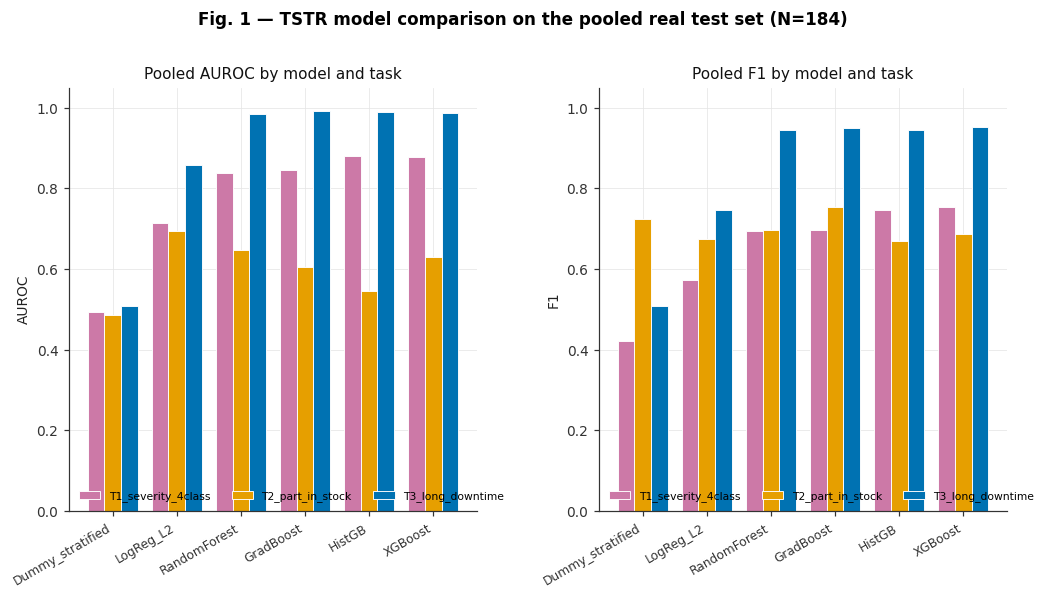

[SAVED] fig1_model_comparison.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


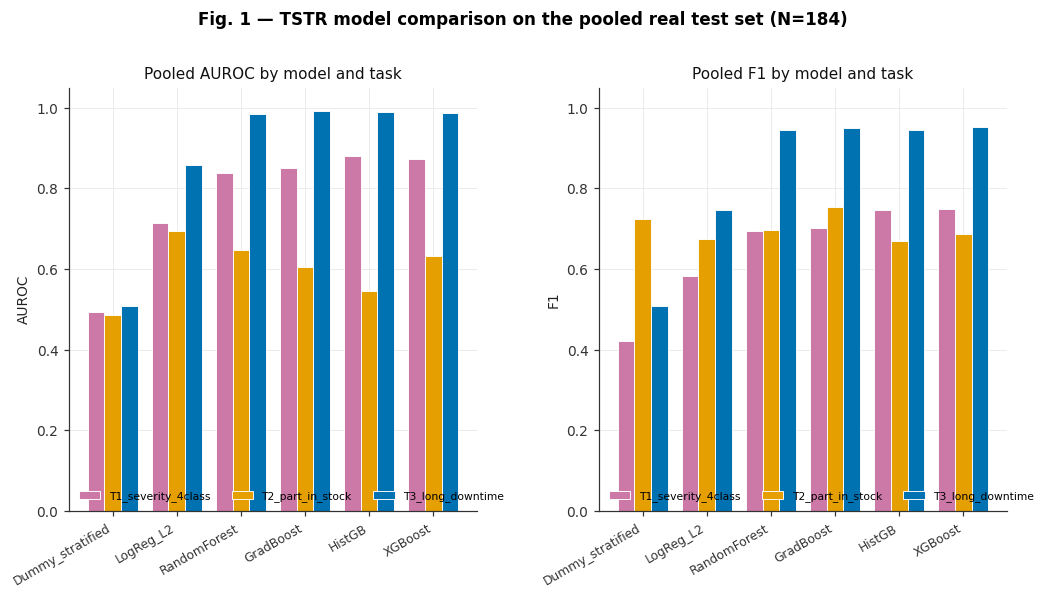

[SAVED] fig1_model_comparison.png


In [47]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 1 — Model comparison across tasks (pooled AUROC and F1)
# ═══════════════════════════════════════════════════════════════════════════

fig1 = plt.figure(figsize=(11, 5))
gs1  = gridspec.GridSpec(1, 2, figure=fig1, wspace=0.30)

models_ord = ['Dummy_stratified','LogReg_L2','RandomForest',
              'GradBoost','HistGB','XGBoost']
tasks_ord  = list(TASKS.keys())

for panel_i, metric in enumerate(['auroc', 'f1']):
    ax = fig1.add_subplot(gs1[0, panel_i])
    x = np.arange(len(models_ord))
    width = 0.26
    for i, task_key in enumerate(tasks_ord):
        task_row = pooled_results[pooled_results['task'] == task_key]
        values = [task_row[task_row['model'] == m][metric].values[0]
                  for m in models_ord]
        ax.bar(x + (i-1)*width, values, width=width,
               label=task_key, color=TASK_COLORS[task_key],
               edgecolor='white', linewidth=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels(models_ord, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(metric.upper())
    ax.set_ylim(0, 1.05)
    ax.set_title(f'Pooled {metric.upper()} by model and task', fontsize=10)
    ax.legend(loc='lower left', ncol=3, frameon=False, fontsize=7)
    _thin_spines(ax)

fig1.suptitle('Fig. 1 — TSTR model comparison on the pooled real test set (N=184)',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig(str(OUTPUT_DIR / 'fig1_model_comparison.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig1_model_comparison.png")


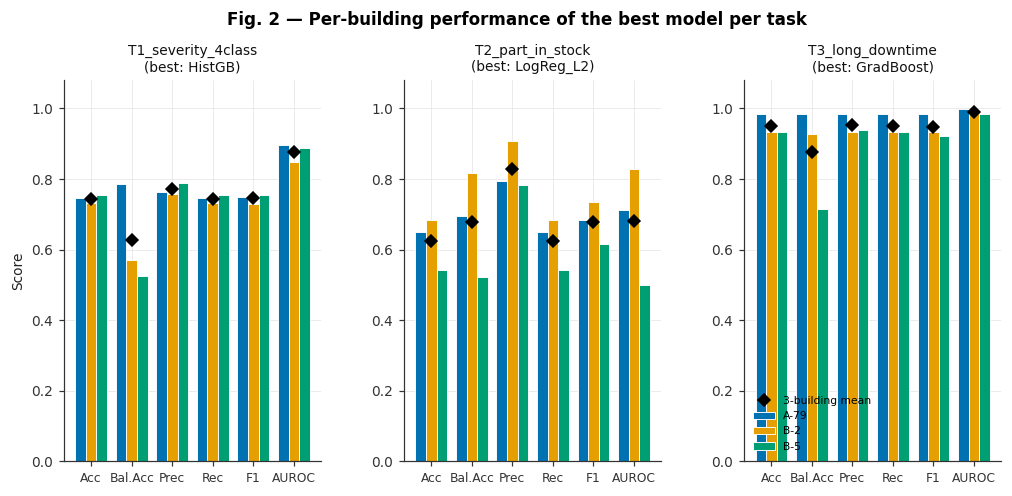

[SAVED] fig2_per_building.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


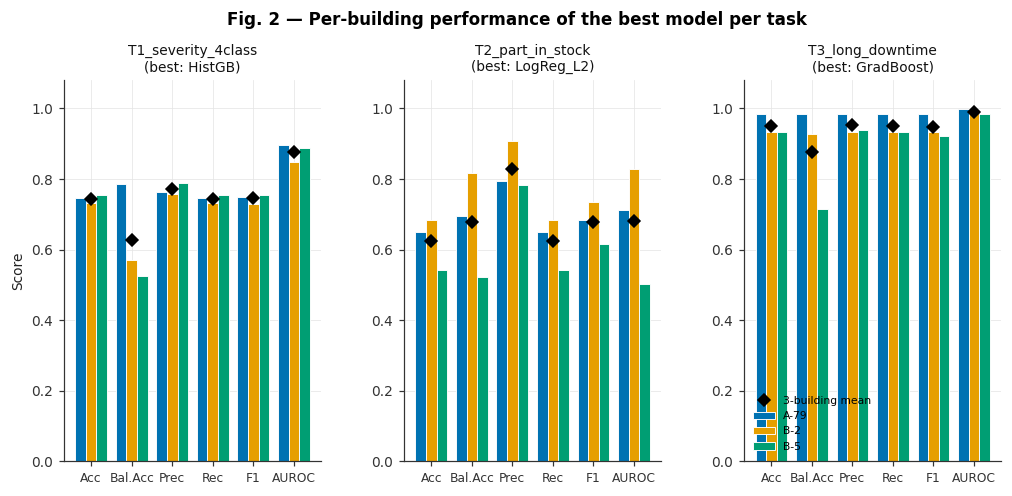

[SAVED] fig2_per_building.png


In [48]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 2 — Per-building performance of best model for each task
# ═══════════════════════════════════════════════════════════════════════════

fig2 = plt.figure(figsize=(11, 4.5))
gs2  = gridspec.GridSpec(1, 3, figure=fig2, wspace=0.32)

building_order = list(real_dfs.keys())
display_metrics = ['accuracy','balanced_acc','precision','recall','f1','auroc']
metric_labels   = ['Acc','Bal.Acc','Prec','Rec','F1','AUROC']

for ti, task_key in enumerate(tasks_ord):
    ax = fig2.add_subplot(gs2[0, ti])
    rows = per_building_results[per_building_results['task'] == task_key]
    x = np.arange(len(display_metrics))
    width = 0.26
    for i, bld in enumerate(building_order):
        vals = rows[rows['building'] == bld][display_metrics].values.flatten()
        ax.bar(x + (i-1)*width, vals, width=width,
               label=f'{bld}', color=BUILDING_COLORS[bld],
               edgecolor='white', linewidth=0.6)
    mean_vals = rows[display_metrics].mean().values
    ax.plot(x, mean_vals, marker='D', linestyle='', color='black',
            markersize=6, label='3-building mean', zorder=5)
    ax.set_xticks(x); ax.set_xticklabels(metric_labels, fontsize=8)
    ax.set_ylim(0, 1.08)
    best_model_name = best_model_per_task[task_key]
    ax.set_title(f'{task_key}\n(best: {best_model_name})', fontsize=9)
    if ti == 0: ax.set_ylabel('Score')
    if ti == 2: ax.legend(loc='lower left', frameon=False, fontsize=7)
    _thin_spines(ax)

fig2.suptitle('Fig. 2 — Per-building performance of the best model per task',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig(str(OUTPUT_DIR / 'fig2_per_building.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig2_per_building.png")


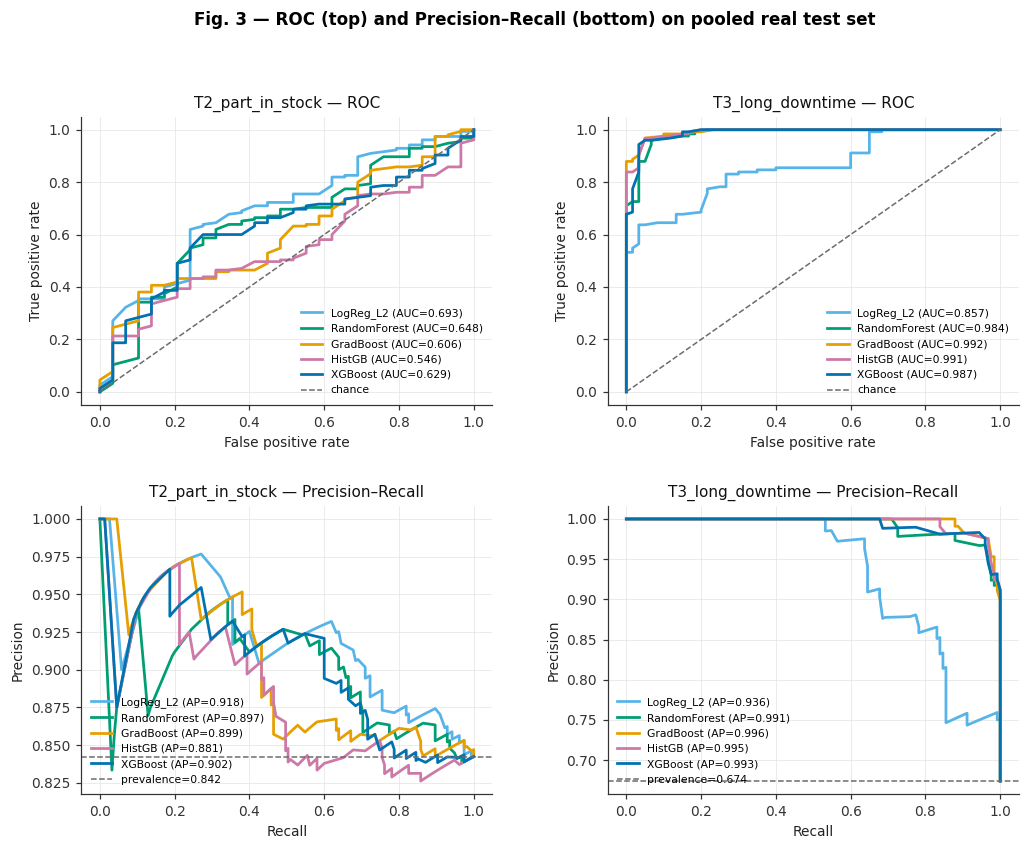

[SAVED] fig3_roc_pr_curves.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


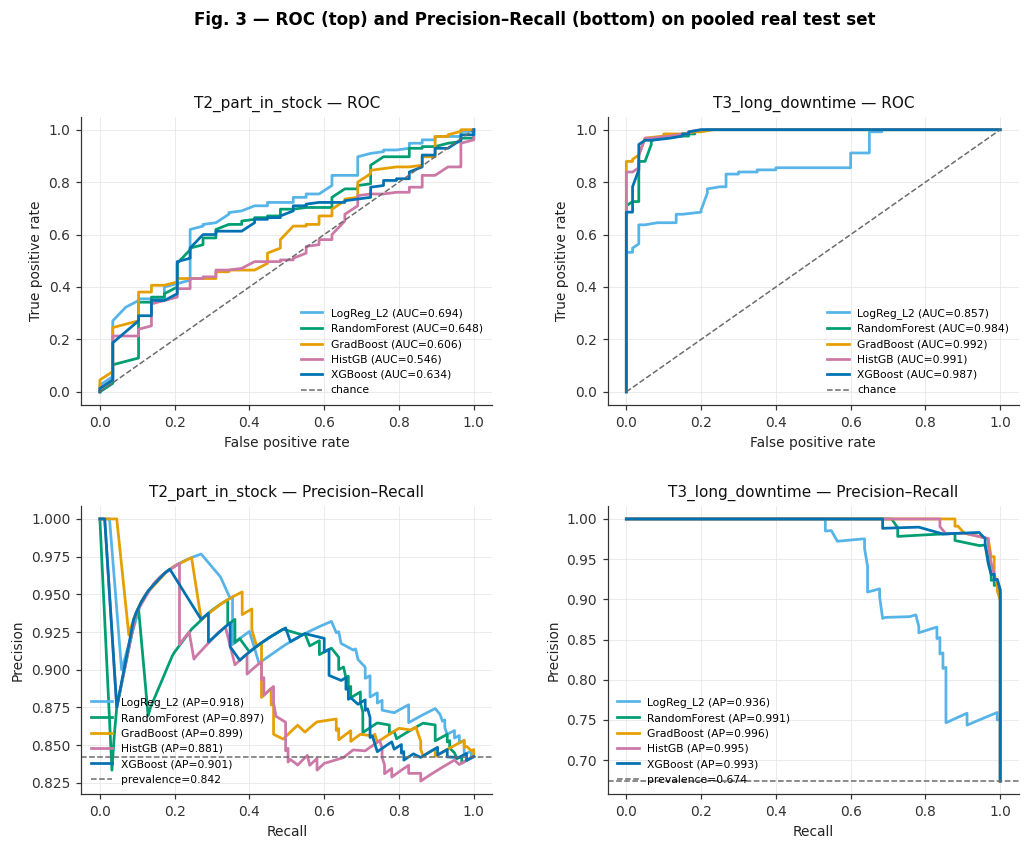

[SAVED] fig3_roc_pr_curves.png


In [49]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 3 — ROC and Precision–Recall curves for binary tasks
# ═══════════════════════════════════════════════════════════════════════════

binary_tasks = [t for t in tasks_ord if TASKS[t]['is_binary']]

fig3 = plt.figure(figsize=(11, 8))
gs3  = gridspec.GridSpec(2, len(binary_tasks), figure=fig3,
                        wspace=0.28, hspace=0.35)

for ti, task_key in enumerate(binary_tasks):
    # ROC row
    ax_roc = fig3.add_subplot(gs3[0, ti])
    for model_name in ['LogReg_L2','RandomForest','GradBoost',
                       'HistGB','XGBoost']:
        pred = test_predictions[(task_key, model_name)]
        if pred['y_proba'] is None: continue
        fpr, tpr, _ = roc_curve(pred['y_true'], pred['y_proba'][:, 1])
        auc_val = roc_auc_score(pred['y_true'], pred['y_proba'][:, 1])
        ax_roc.plot(fpr, tpr, color=MODEL_COLORS[model_name], lw=1.8,
                    label=f'{model_name} (AUC={auc_val:.3f})')
    ax_roc.plot([0,1],[0,1], '--', color=C_GREY, lw=1, label='chance')
    ax_roc.set_xlabel('False positive rate')
    ax_roc.set_ylabel('True positive rate')
    ax_roc.set_title(f'{task_key} — ROC')
    ax_roc.legend(loc='lower right', frameon=False, fontsize=7)
    _thin_spines(ax_roc)

    # Precision–Recall row
    ax_pr = fig3.add_subplot(gs3[1, ti])
    for model_name in ['LogReg_L2','RandomForest','GradBoost',
                       'HistGB','XGBoost']:
        pred = test_predictions[(task_key, model_name)]
        if pred['y_proba'] is None: continue
        prec, rec, _ = precision_recall_curve(pred['y_true'], pred['y_proba'][:, 1])
        ap = average_precision_score(pred['y_true'], pred['y_proba'][:, 1])
        ax_pr.plot(rec, prec, color=MODEL_COLORS[model_name], lw=1.8,
                   label=f'{model_name} (AP={ap:.3f})')
    prevalence = float(test_predictions[(task_key, 'XGBoost')]['y_true'].mean())
    ax_pr.axhline(prevalence, linestyle='--', color=C_GREY, lw=1,
                  label=f'prevalence={prevalence:.3f}')
    ax_pr.set_xlabel('Recall')
    ax_pr.set_ylabel('Precision')
    ax_pr.set_title(f'{task_key} — Precision–Recall')
    ax_pr.legend(loc='lower left', frameon=False, fontsize=7)
    _thin_spines(ax_pr)

fig3.suptitle('Fig. 3 — ROC (top) and Precision–Recall (bottom) on pooled real test set',
              fontsize=11, fontweight='bold', y=1.00)
plt.savefig(str(OUTPUT_DIR / 'fig3_roc_pr_curves.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig3_roc_pr_curves.png")


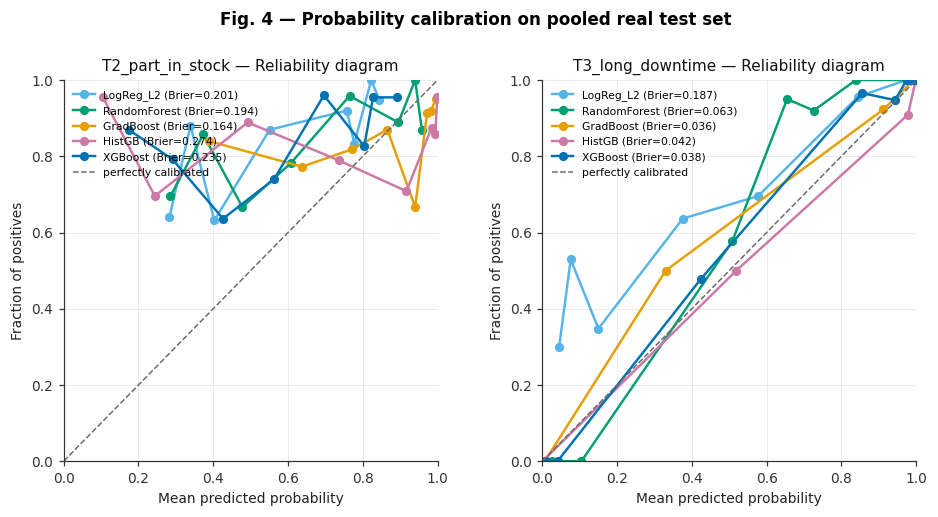

[SAVED] fig4_calibration.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


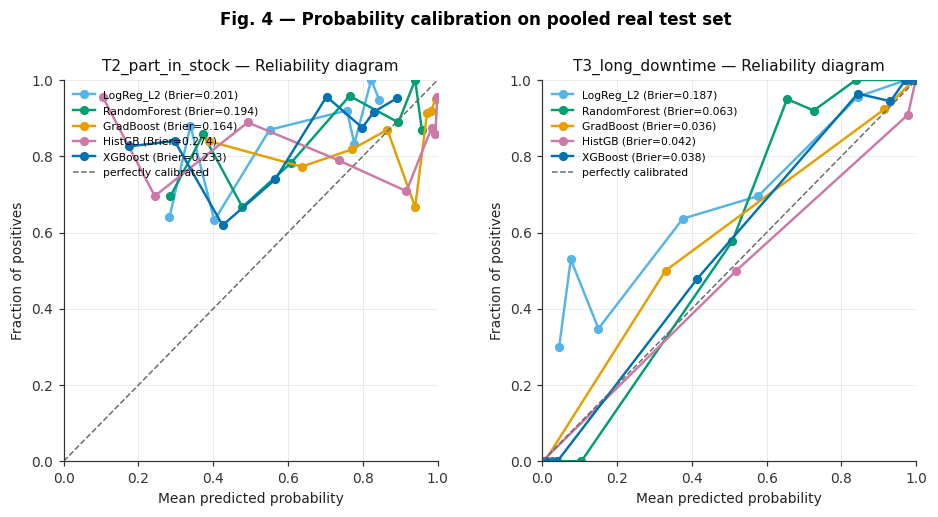

[SAVED] fig4_calibration.png


In [50]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 4 — Probability calibration (reliability diagrams) for binary tasks
# ═══════════════════════════════════════════════════════════════════════════

fig4 = plt.figure(figsize=(10, 4.5))
gs4  = gridspec.GridSpec(1, len(binary_tasks), figure=fig4, wspace=0.28)

for ti, task_key in enumerate(binary_tasks):
    ax = fig4.add_subplot(gs4[0, ti])
    for model_name in ['LogReg_L2','RandomForest','GradBoost','HistGB','XGBoost']:
        pred = test_predictions[(task_key, model_name)]
        if pred['y_proba'] is None: continue
        prob_true, prob_pred = calibration_curve(
            pred['y_true'], pred['y_proba'][:, 1],
            n_bins=8, strategy='quantile')
        brier = brier_score_loss(pred['y_true'], pred['y_proba'][:, 1])
        ax.plot(prob_pred, prob_true, marker='o',
                color=MODEL_COLORS[model_name], lw=1.6, ms=5,
                label=f'{model_name} (Brier={brier:.3f})')
    ax.plot([0,1],[0,1],'--',color=C_GREY,lw=1,label='perfectly calibrated')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives')
    ax.set_title(f'{task_key} — Reliability diagram')
    ax.set_xlim(0,1); ax.set_ylim(0,1)
    ax.legend(loc='upper left', frameon=False, fontsize=7)
    _thin_spines(ax)

fig4.suptitle('Fig. 4 — Probability calibration on pooled real test set',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig(str(OUTPUT_DIR / 'fig4_calibration.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig4_calibration.png")


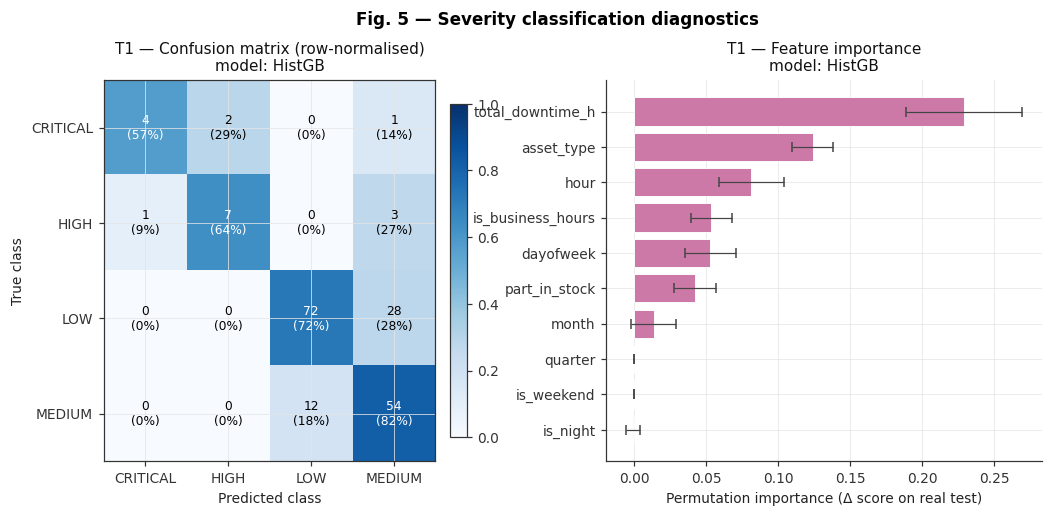

[SAVED] fig5_T1_diagnostics.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


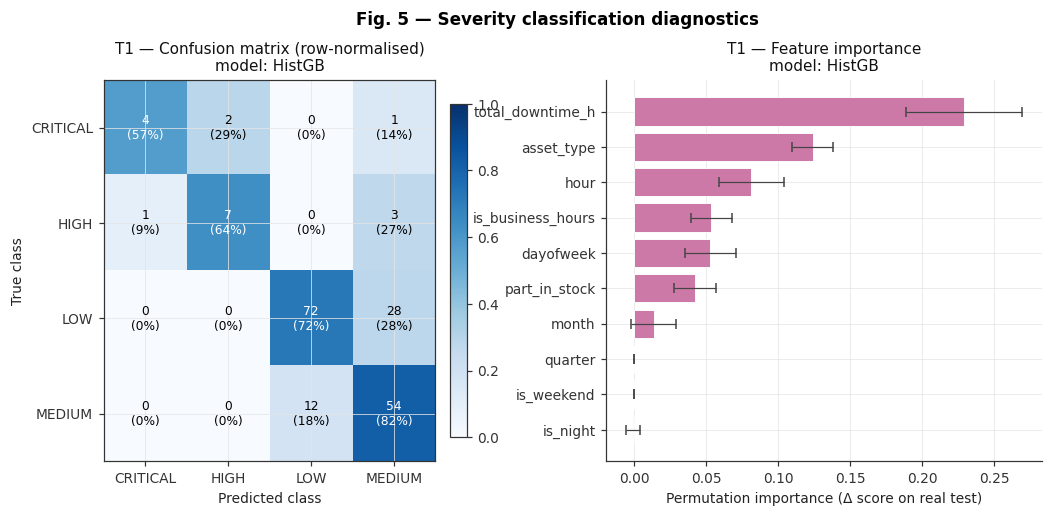

[SAVED] fig5_T1_diagnostics.png


In [51]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 5 — T1 severity confusion matrix + permutation importance
# ═══════════════════════════════════════════════════════════════════════════

fig5 = plt.figure(figsize=(11, 4.5))
gs5  = gridspec.GridSpec(1, 2, figure=fig5, width_ratios=[1, 1.2], wspace=0.35)

# ── Confusion matrix (heatmap) ─────────────────────────────────────────────
ax_cm = fig5.add_subplot(gs5[0, 0])
cm_norm = cm / cm.sum(axis=1, keepdims=True)
im = ax_cm.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1, aspect='auto')
ax_cm.set_xticks(range(len(class_names)))
ax_cm.set_xticklabels(class_names, rotation=0)
ax_cm.set_yticks(range(len(class_names)))
ax_cm.set_yticklabels(class_names)
ax_cm.set_xlabel('Predicted class')
ax_cm.set_ylabel('True class')
ax_cm.set_title(f'T1 — Confusion matrix (row-normalised)\nmodel: {T1_model_name}')
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax_cm.text(j, i, f'{cm[i,j]}\n({cm_norm[i,j]*100:.0f}%)',
                   ha='center', va='center', fontsize=8,
                   color='white' if cm_norm[i,j] > 0.5 else 'black')
plt.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)

# ── Permutation importance for the T1 best model ──────────────────────────
ax_fi = fig5.add_subplot(gs5[0, 1])
imp_df = feature_importance_tables['T1_severity_4class']
ax_fi.barh(imp_df['feature'], imp_df['importance_mean'],
           xerr=imp_df['importance_std'],
           color=C_PURPLE, edgecolor='white', linewidth=0.6,
           error_kw={'ecolor':'#444','capsize':3,'lw':0.8})
ax_fi.invert_yaxis()
ax_fi.set_xlabel('Permutation importance (Δ score on real test)')
ax_fi.set_title(f'T1 — Feature importance\nmodel: {T1_model_name}')
_thin_spines(ax_fi)

fig5.suptitle('Fig. 5 — Severity classification diagnostics',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig(str(OUTPUT_DIR / 'fig5_T1_diagnostics.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig5_T1_diagnostics.png")


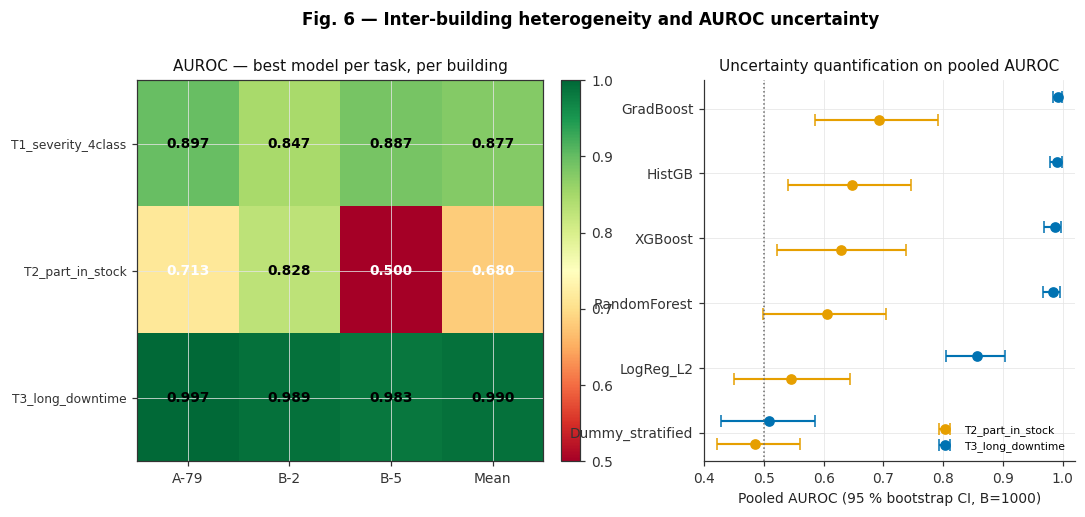

[SAVED] fig6_heterogeneity_ci.png


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


...

findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.


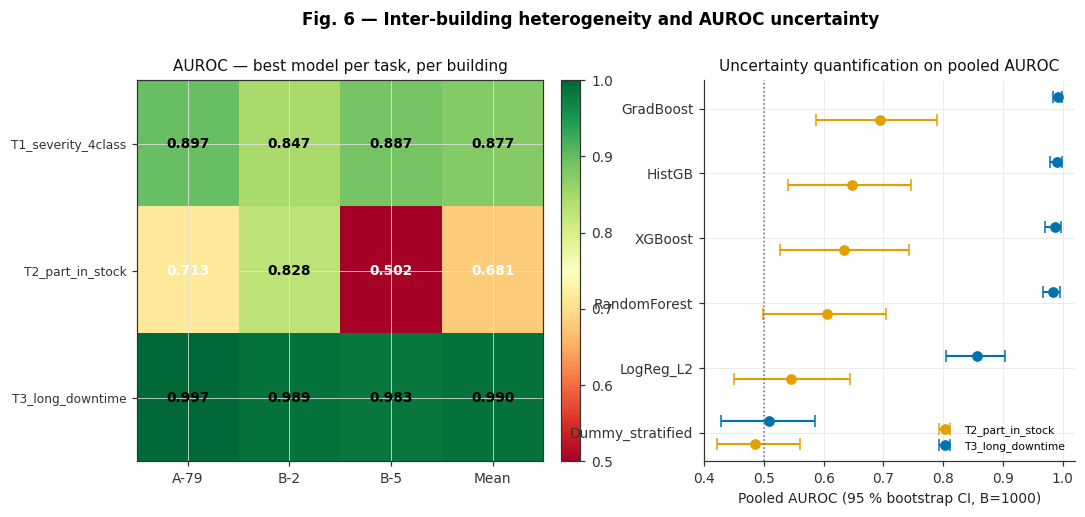

[SAVED] fig6_heterogeneity_ci.png


In [52]:
# ═══════════════════════════════════════════════════════════════════════════
# FIGURE 6 — Inter-building heterogeneity heatmap + bootstrap CIs
# ═══════════════════════════════════════════════════════════════════════════

fig6 = plt.figure(figsize=(11, 4.5))
gs6  = gridspec.GridSpec(1, 2, figure=fig6, width_ratios=[1.2, 1], wspace=0.30)

# ── Heatmap: AUROC per task × building ────────────────────────────────────
ax_hm = fig6.add_subplot(gs6[0, 0])
hm_data = np.zeros((len(tasks_ord), len(building_order)+1))
for i, tk in enumerate(tasks_ord):
    rows = per_building_results[per_building_results['task'] == tk]
    for j, bld in enumerate(building_order):
        hm_data[i, j] = rows[rows['building']==bld]['auroc'].values[0]
    hm_data[i, -1] = rows['auroc'].mean()
col_labels = building_order + ['Mean']
im = ax_hm.imshow(hm_data, cmap='RdYlGn', vmin=0.5, vmax=1.0, aspect='auto')
ax_hm.set_xticks(range(len(col_labels)))
ax_hm.set_xticklabels(col_labels)
ax_hm.set_yticks(range(len(tasks_ord)))
ax_hm.set_yticklabels(tasks_ord, fontsize=8)
ax_hm.set_title('AUROC — best model per task, per building')
for i in range(hm_data.shape[0]):
    for j in range(hm_data.shape[1]):
        v = hm_data[i, j]
        ax_hm.text(j, i, f'{v:.3f}', ha='center', va='center',
                   fontsize=9, fontweight='bold',
                   color='black' if v > 0.75 else 'white')
plt.colorbar(im, ax=ax_hm, fraction=0.046, pad=0.04)

# ── Bootstrap CIs — pooled AUROC ──────────────────────────────────────────
ax_ci = fig6.add_subplot(gs6[0, 1])
if len(bootstrap_df) > 0:
    for task_key in binary_tasks:
        sub = bootstrap_df[bootstrap_df['task'] == task_key].copy()
        sub = sub.sort_values('auroc', ascending=True)
        y_pos = np.arange(len(sub))
        ax_ci.errorbar(sub['auroc'].values, y_pos + (0 if task_key==binary_tasks[0] else 0.35),
                       xerr=[sub['auroc'].values - sub['ci_lo_95'].values,
                             sub['ci_hi_95'].values - sub['auroc'].values],
                       fmt='o', color=TASK_COLORS[task_key], capsize=4,
                       label=task_key, markersize=6, lw=1.4)
    n_models = len(pooled_results[pooled_results['task']==binary_tasks[0]])
    ax_ci.set_yticks(np.arange(n_models) + 0.175)
    ax_ci.set_yticklabels(sub['model'].values)
ax_ci.set_xlabel('Pooled AUROC (95 % bootstrap CI, B=1000)')
ax_ci.set_title('Uncertainty quantification on pooled AUROC')
ax_ci.set_xlim(0.4, 1.02)
ax_ci.axvline(0.5, linestyle=':', color=C_GREY, lw=1)
ax_ci.legend(loc='lower right', frameon=False, fontsize=7)
_thin_spines(ax_ci)

fig6.suptitle('Fig. 6 — Inter-building heterogeneity and AUROC uncertainty',
              fontsize=11, fontweight='bold', y=1.02)
plt.savefig(str(OUTPUT_DIR / 'fig6_heterogeneity_ci.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("[SAVED] fig6_heterogeneity_ci.png")


## 19. Persist deliverables
Output CSVs for inclusion as supplementary material. Figures have already been saved at 300 DPI in the visualisation cells above.


In [54]:
# OUTPUT_DIR already defined in cell 4 (derived from INPUT_DIR)

pooled_results.to_csv(OUTPUT_DIR / 'tstr_pooled_all_models.csv', index=False)
per_building_results.to_csv(OUTPUT_DIR / 'tstr_per_building_best_model.csv', index=False)
aggregate_mean.to_csv(OUTPUT_DIR / 'tstr_aggregate_mean.csv')
aggregate_std.to_csv(OUTPUT_DIR / 'tstr_aggregate_std.csv')
real_summary.to_csv(OUTPUT_DIR / 'real_buildings_descriptive.csv')
cm_df.to_csv(OUTPUT_DIR / 'T1_severity_confusion_matrix.csv')
if len(bootstrap_df) > 0:
    bootstrap_df.to_csv(OUTPUT_DIR / 'bootstrap_auroc_ci.csv', index=False)
for tk, imp_df in feature_importance_tables.items():
    imp_df.to_csv(OUTPUT_DIR / f'permutation_importance_{tk}.csv', index=False)

print("Deliverables written:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  · {f.name}  ({f.stat().st_size:,} bytes)")


Deliverables written:
  · bootstrap_auroc_ci.csv  (629 bytes)
  · building_simulation_rome_corrected  (4,096 bytes)
  · fig1_model_comparison.png  (145,755 bytes)
  · fig2_per_building.png  (107,237 bytes)
  · fig3_roc_pr_curves.png  (488,806 bytes)
  · fig4_calibration.png  (371,744 bytes)
  · fig5_T1_diagnostics.png  (213,686 bytes)
  · fig6_heterogeneity_ci.png  (205,801 bytes)
  · permutation_importance_T1_severity_4class.csv  (288 bytes)
  · permutation_importance_T2_part_in_stock.csv  (265 bytes)
  · permutation_importance_T3_long_downtime.csv  (295 bytes)
  · real_buildings_descriptive.csv  (325 bytes)
  · T1_severity_confusion_matrix.csv  (132 bytes)
  · tstr_aggregate_mean.csv  (233 bytes)
  · tstr_aggregate_std.csv  (232 bytes)
  · tstr_per_building_best_model.csv  (863 bytes)
  · tstr_pooled_all_models.csv  (3,084 bytes)


## 20. Summary of findings

This section reports observations grounded exclusively in the metrics computed in the preceding cells. All quantitative values are available in the CSV deliverables of section 19.

**Pooled performance** (section 12) ranks the six classifiers by AUROC within each task. XGBoost with task-specific class-imbalance correction (`scale_pos_weight` for binary tasks) is evaluated alongside the existing panel to characterise the upper envelope of achievable performance on the intersection feature space.

**Inter-building variability** (section 14 and Figure 6 heatmap) quantifies the spread of the best-model metrics across buildings A-79, B-2, B-5. Larger spread on a given task indicates deviation of real-building behaviour from the synthetic generator that affects generalisation.

**Uncertainty** on pooled AUROC (section 15 and Figure 6 error bars) is estimated via 1 000 bootstrap resamples of the pooled real test set, providing 95 % confidence intervals. These are necessary for any claim of superiority between models given the small real-world sample size (N=184).

**Diagnostics** for the severity task (section 16 and Figure 5) expose which severity transitions are confused by the best model, and which features drive predictions on real data as measured by permutation importance.

**Scope and limitations.** The intersection of synthetic and real schemas contains only the columns listed in section 3. Physics-specific features of the PM v4.0 generator (for example `arrhenius_stress_factor`, `health_index`, `rul_remaining_h`, `cascade_probability_adjusted`) are absent from the real test files and therefore cannot be evaluated through the present protocol. Performance reported here characterises transfer on the shared feature space and is not a direct measure of the contribution of the physics-informed modelling layer.
